In [2]:
import kaggle
from distributed.utils import palette

kaggle.api.authenticate()
kaggle.api.dataset_download_files('andrewmvd/okcupid-profiles', path='.', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/okcupid-profiles


# OkCupid - Data Science Project

Leave Introduction for the end, right now I don't really know what i am focusing on, first I want to analyze the data.
Ideas that I find interesting for the objective:
1. Sociological Approach: Education level vs Religion (How does reported education influence people's beliefs.)
2. The NLP problem: Predict Relationship Intent with K-Means (What type of relationship are people looking for)
3. Classification problem: Predict Education level based on their essays (length, vocabulary and income)

### Setup for Objectives

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
#Turn our csv into a dataframe
profiles = pd.read_csv('../Dataset/okcupid_profiles.csv')
profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   sex          59946 non-null  object 
 3   orientation  59946 non-null  object 
 4   body_type    54650 non-null  object 
 5   diet         35551 non-null  object 
 6   drinks       56961 non-null  object 
 7   drugs        45866 non-null  object 
 8   education    53318 non-null  object 
 9   ethnicity    54266 non-null  object 
 10  height       59943 non-null  float64
 11  income       59946 non-null  int64  
 12  job          51748 non-null  object 
 13  last_online  59946 non-null  object 
 14  location     59946 non-null  object 
 15  offspring    24385 non-null  object 
 16  pets         40025 non-null  object 
 17  religion     39720 non-null  object 
 18  sign         48890 non-null  object 
 19  smok

## Sociological Approach: Education level vs Religion
I wanted to start by modeling something that I personally find interesting. And see what I find


### Setting clear buckets for the education level

In [3]:
#Take a look at what values we have to see how we classify the data
# print(profiles['education'].unique())
#The function to separate into distinct buckets
def segment_education(status):
    # Handle NaNs
    if pd.isna(status):
        return 'not specified'
    status = status.lower()
    # 1.Noise Category
    if 'space camp' in status:
        return 'space camp'
    # 2. Dropped Out
    if 'dropped out' in status:
        return 'dropped out'
    # 3. Post-Graduate
    if any(edu in status for edu in ['masters', 'ph.d', 'law school', 'med school']):
        return 'post-grad'
    # 4. Undergraduate
    if any(edu in status for edu in ['college', 'university', 'two-year college']):
        return 'undergrad'
    # 5. High School
    if 'high school' in status:
        return 'high school'

    return 'other'

profiles['edu_cleaned'] = profiles['education'].apply(segment_education)

### Setting clear buckets for religion

In [4]:
#print(profiles['religion'].unique())
# All strings follow the same pattern: They first state their religion and then how serious they take it
def clean_religion(entry):
    if pd.isna(entry):
        return 'not specified'
    entry = entry.lower()
    religion = entry.split(' and ')[0].split(' but ')[0]
    return religion.strip()

profiles['religion_cleaned'] = profiles['religion'].apply(clean_religion)

def extract_seriousness(entry):
    if pd.isna(entry):
        return 'not specified'

    entry = entry.lower()
    if 'very serious' in entry:
        return 'high' # Or 3
    elif 'somewhat serious' in entry:
        return 'medium' # Or 2
    elif 'not too serious' in entry:
        return 'low' # Or 1
    elif 'laughing about it' in entry:
        return 'minimal/ironic' # Or 0

    return 'neutral' # For entries like just "atheism" or "christianity"

profiles['religion_seriousness'] = profiles['religion'].apply(extract_seriousness)
#print(profiles['religion_seriousness'].unique())


### Plots after some data cleaning

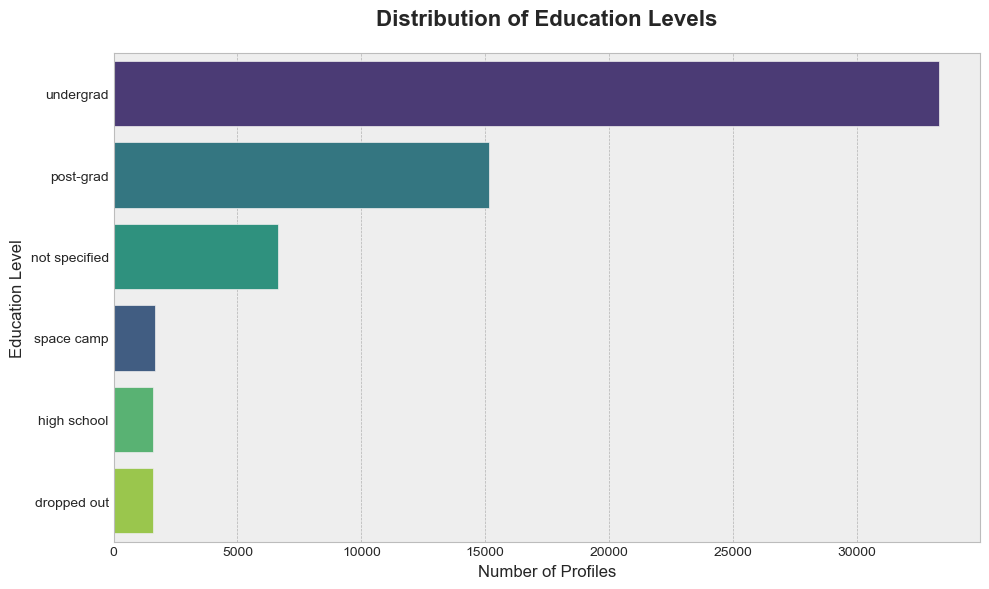

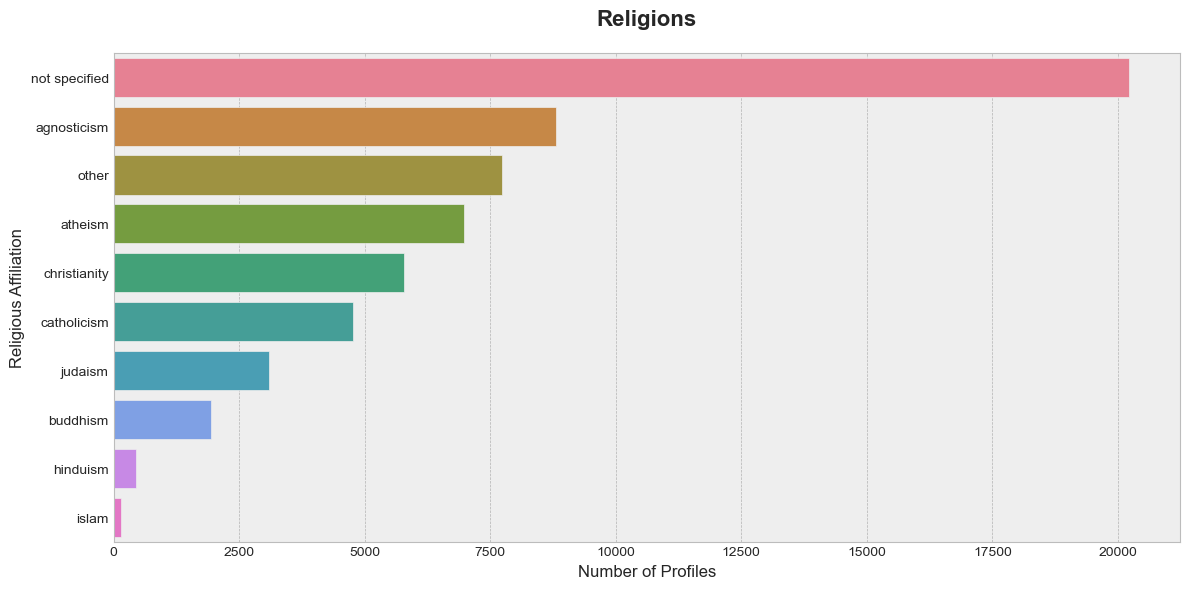

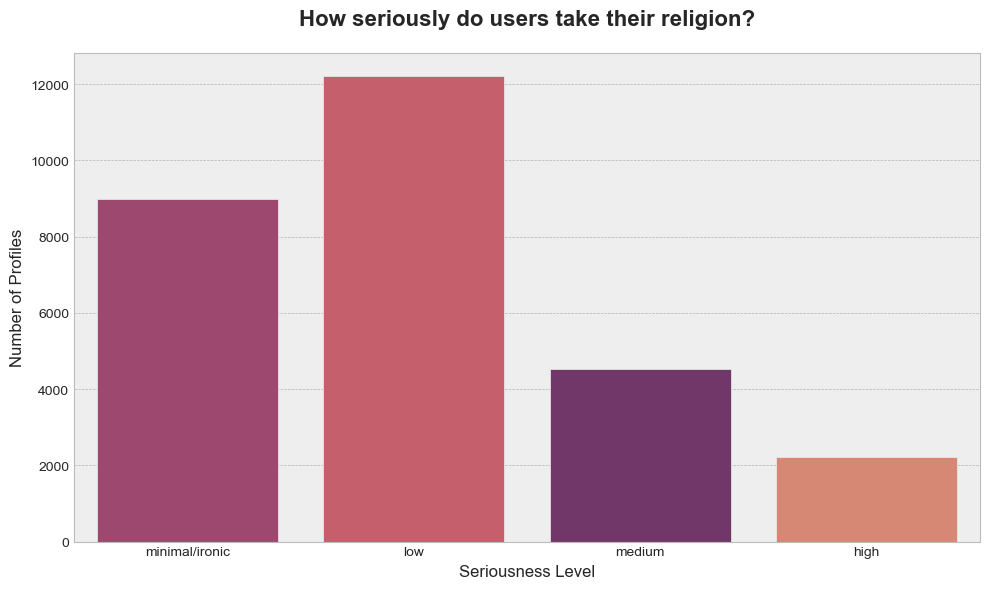

In [5]:
# Style of figures
plt.style.use('bmh')
sns.set_palette('viridis')

# 1 Distribution of education levels
plt.figure(figsize=(10, 6))
order = profiles['edu_cleaned'].value_counts().index
sns.countplot(data=profiles, y='edu_cleaned', hue='edu_cleaned', order= order)

plt.title('Distribution of Education Levels', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Profiles', fontsize=12)
plt.ylabel('Education Level', fontsize=12)

plt.tight_layout()
plt.show()
#2 Religious distribution levels
plt.figure(figsize=(12, 6))
religion_counts = profiles['religion_cleaned'].value_counts()
sns.barplot(x=religion_counts.values, y=religion_counts.index, hue=religion_counts.index)
plt.title('Religions', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Profiles', fontsize=12)
plt.ylabel('Religious Affiliation', fontsize=12)
plt.tight_layout()
plt.show()

#3 How religious are the people
serious_df = profiles[(profiles['religion_seriousness'] != 'not specified') & (profiles['religion_seriousness'] != 'neutral')]
#print(serious_df.head)
plt.figure(figsize=(10, 6))

seriousness_order = ['minimal/ironic', 'low', 'medium', 'high']

sns.countplot(data=serious_df, x='religion_seriousness', hue='religion_seriousness', order=seriousness_order, palette='flare')

plt.title('How seriously do users take their religion?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Seriousness Level', fontsize=12)
plt.ylabel('Number of Profiles', fontsize=12)
plt.tight_layout()
plt.show()

### Exploring the Education vs Religion problem


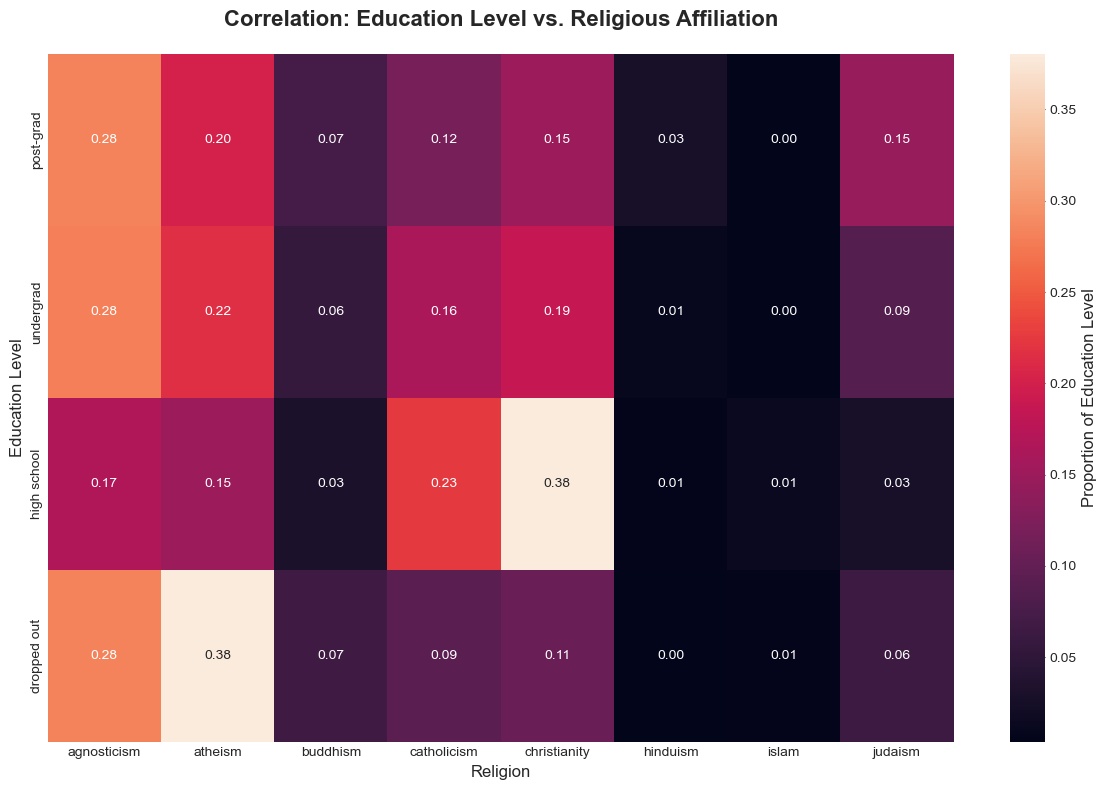

Chi-Square Statistic: 1086.9981638034687
P-value: 7.92581324711559e-217


In [6]:

noise_rel = ['not specified', 'other']
edu_order = ['post-grad', 'undergrad', 'high school', 'dropped out']

df_clean = profiles[(profiles['edu_cleaned'].isin(edu_order)) & (~profiles['religion_cleaned'].isin(noise_rel))].copy()


# 2. Create the Contingency Table (Cross-tabulation)
# 'normalize="index"' scales the rows so they add up to 100%
cross_tab = pd.crosstab(df_clean['edu_cleaned'], df_clean['religion_cleaned'], normalize='index')
cross_tab_ordered = cross_tab.reindex(index=edu_order)
# 3. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab_ordered, annot=True, fmt=".2f", cmap="rocket", cbar_kws={'label': 'Proportion of Education Level'})

plt.title('Correlation: Education Level vs. Religious Affiliation', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Religion', fontsize=12)
plt.ylabel('Education Level', fontsize=12)
plt.tight_layout()
plt.show()

# Run the chi test on raw data,
raw_cross_tab = pd.crosstab(df_clean['edu_cleaned'], df_clean['religion_cleaned'])
chi2, patch, dof, expected = chi2_contingency(raw_cross_tab)

print(f'Chi-Square Statistic: {chi2}')
print(f'P-value: {patch}')

edu_cleaned
dropped out     334
high school     629
post-grad      4444
undergrad      9327
dtype: int64
religion_seriousness  high  minimal/ironic
edu_cleaned                               
dropped out             23              84
high school             77              30
post-grad              206             681
undergrad              421            1295


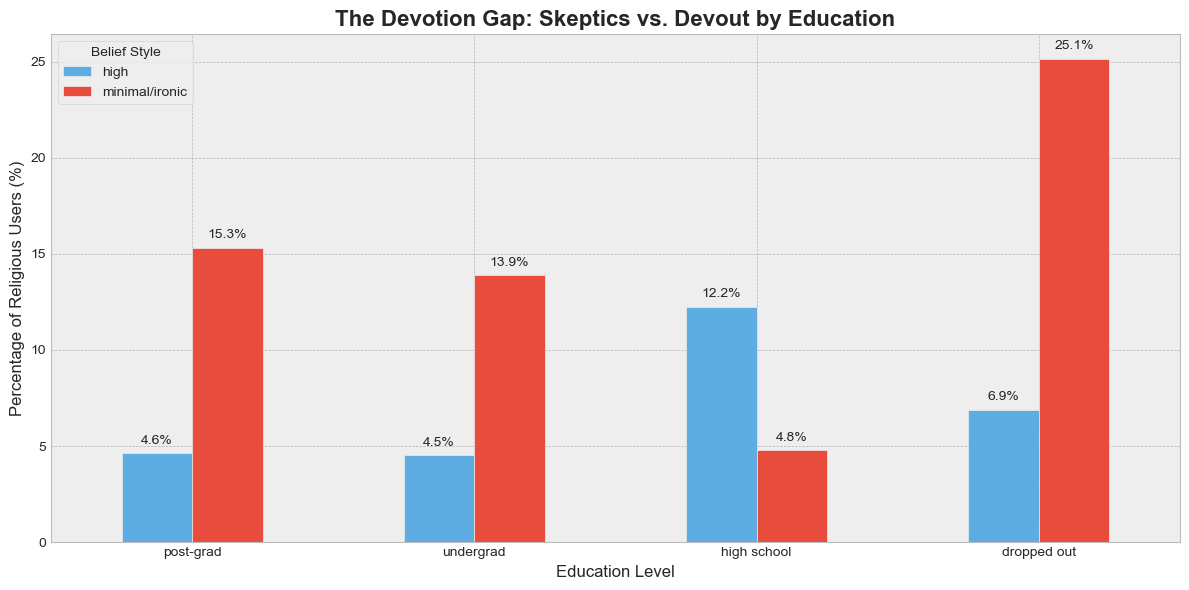

In [7]:
# Define the extremes
extremes = ['minimal/ironic', 'high']
religions = ['buddhism', 'catholicism', 'christianity', 'hinduism', 'islam', 'judaism']

# Filter the dataset
df_extremes = profiles[(profiles['edu_cleaned'].isin(edu_order)) & (profiles['religion_cleaned'].isin(religions)) & (profiles['religion_seriousness'].isin(extremes))].copy()

# Get total count of religious people per education level
total_religious = profiles[(profiles['edu_cleaned'].isin(edu_order)) & (profiles['religion_cleaned'].isin(religions))].groupby('edu_cleaned').size()
print(total_religious)

# Get counts for the extremes
#unstack basically pivots rows to columns good to know
extreme_counts = df_extremes.groupby(['edu_cleaned', 'religion_seriousness']).size().unstack()
print(extreme_counts)

# Normalize: (Count of Extreme / Total Religious in that Edu Level) * 100
extreme_pct = extreme_counts.div(total_religious, axis=0) * 100
extreme_pct = extreme_pct.reindex(edu_order)

ax = extreme_pct.plot(kind='bar', figsize=(12, 6), color=['#5dade2', '#e74c3c'])

plt.title('The Devotion Gap: Skeptics vs. Devout by Education', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of Religious Users (%)', fontsize=12)
plt.xlabel('Education Level', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Belief Style')

# Adding the value labels
#each rectangle when plotted in a graph is a patch
for patch in ax.patches:
    ax.annotate(f'{patch.get_height():.1f}%', (patch.get_x() + patch.get_width() / 2., patch.get_height()), ha = 'center', va = 'center', xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

## The NLP problem: Predict Relationship Intent

So I am now going to create a K-Means model to predict the intent of users (Long-term relationships, short-term, etc.) and see what clusters appear. For this I will take 4 features into account: Age, Offspring and Essays 0 and 7.

### Removed outliers for the age column

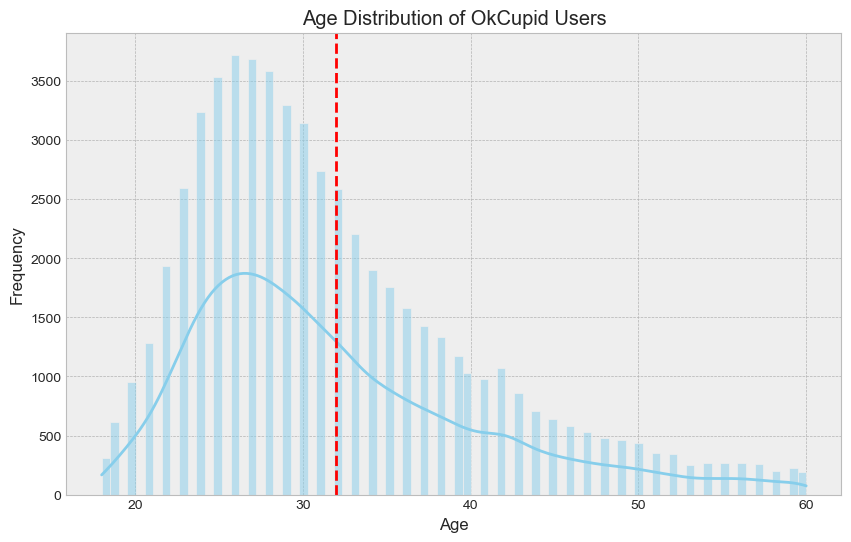

32.0
['m' 'f']


In [8]:
plt.style.use('bmh')
sns.set_palette('viridis')

#(profiles['age'].unique())
clean_df = profiles[profiles['age'] <= 60].copy()
mean_age = clean_df['age'].mean().round()

# 3. Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(data=clean_df['age'], kde=True, color='skyblue', )
plt.axvline(mean_age, color='red', linestyle='--')

# 4. Formatting
plt.title('Age Distribution of OkCupid Users')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
print(mean_age)
print(profiles['sex'].unique())

### Mapping distinct buckets for Offspring column

offspring_score
1    35273
2    15343
3     4414
0     3950
Name: count, dtype: int64


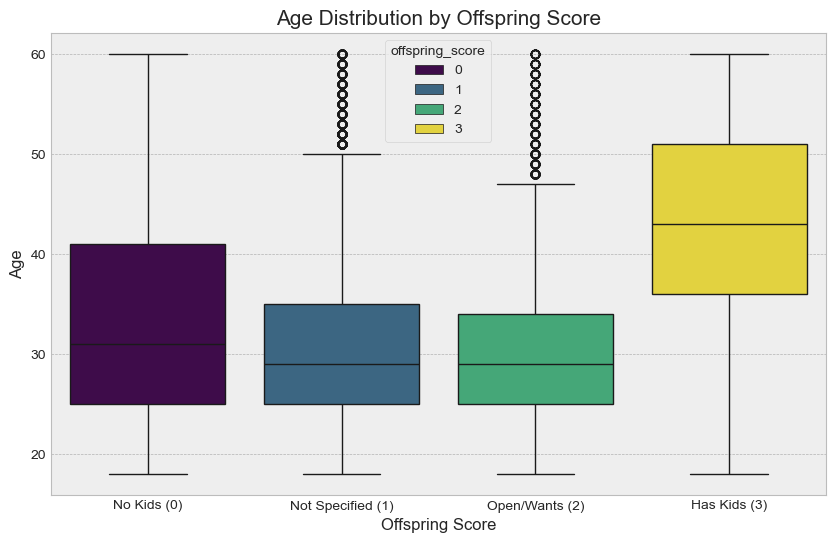

In [9]:
#print(profiles['offspring'].isna().sum())
#print(profiles['offspring'].value_counts())

def map_offspring(text):
    if pd.isna(text):
        return 1  # Not Specified
    text = text.lower()
    # Priority 1: Has kids
    if 'has a kid' in text or 'has kids' in text:
        return 3
    # Priority 2: Open to/Wants kids
    if 'wants' in text or 'might' in text or text == "doesn't have kids":
        # Note: we treat "doesn't have kids" as open/neutral
        # unless they explicitly say "and doesn't want any"
        if "doesn't want" in text:
            return 0
        return 2
    # Priority 3: Explicitly does not want
    if "doesn't want" in text:
        return 0

    return 1 # Fallback for anything else

clean_df['offspring_score'] = clean_df['offspring'].apply(map_offspring)
print(clean_df['offspring_score'].value_counts())
plt.figure(figsize=(10, 6))
sns.boxplot(x='offspring_score', y='age',hue='offspring_score', data=clean_df, palette='viridis')

# 4. Formatting
plt.title('Age Distribution by Offspring Score', fontsize=15)
plt.xlabel('Offspring Score', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.xticks([0, 1, 2, 3], ['No Kids (0)', 'Not Specified (1)', 'Open/Wants (2)', 'Has Kids (3)'])
plt.show()

### Clean essay 0 and 7 columns

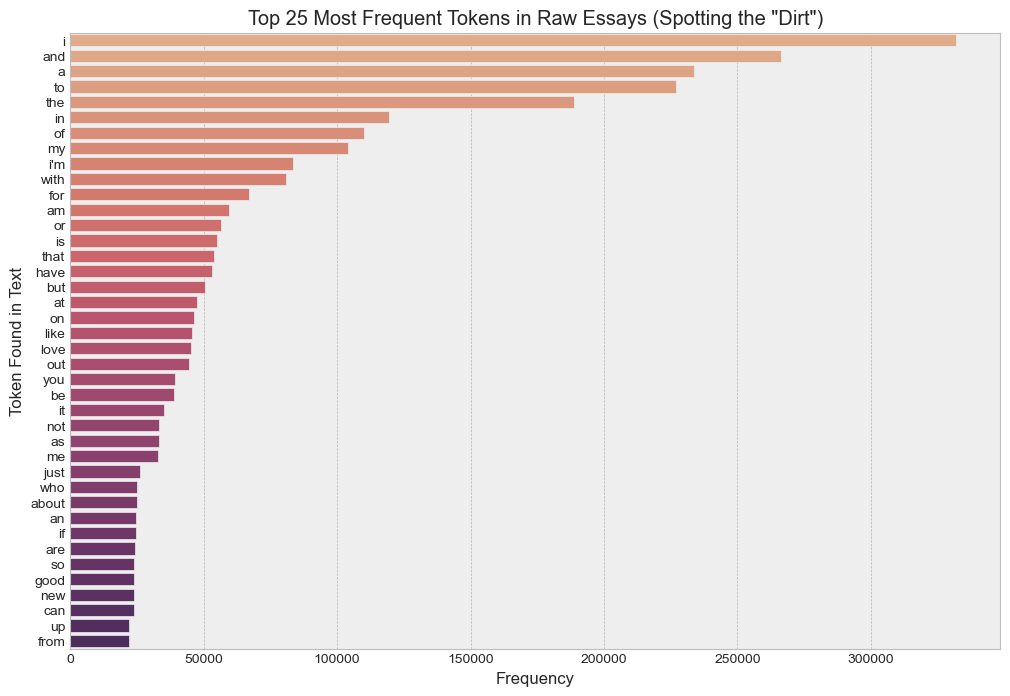

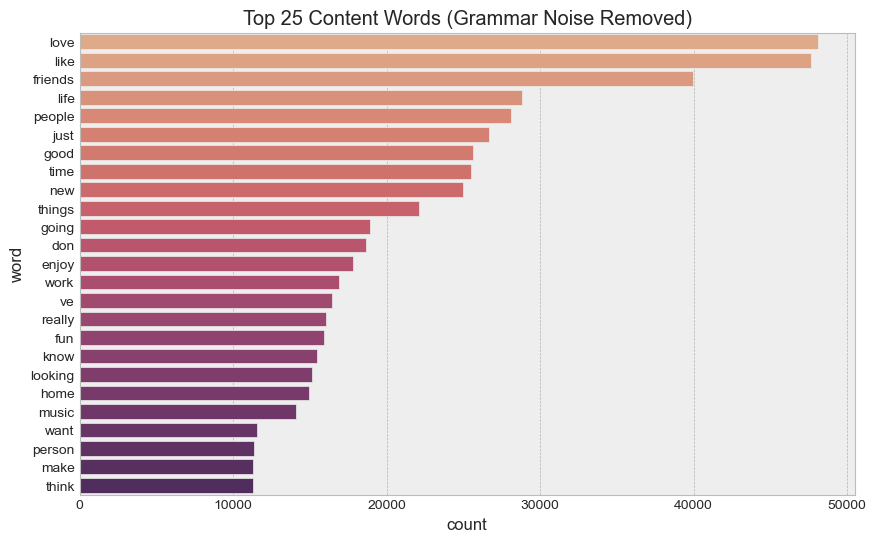

   age     status sex orientation       body_type               diet  \
0   22     single   m    straight  a little extra  strictly anything   
1   35     single   m    straight         average       mostly other   
2   38  available   m    straight            thin           anything   
3   23     single   m    straight            thin         vegetarian   
4   29     single   m    straight        athletic                NaN   

     drinks      drugs                          education  \
0  socially      never      working on college/university   
1     often  sometimes              working on space camp   
2  socially        NaN     graduated from masters program   
3  socially        NaN      working on college/university   
4  socially      never  graduated from college/university   

             ethnicity  ...  \
0         asian, white  ...   
1                white  ...   
2                  NaN  ...   
3                white  ...   
4  asian, black, other  ...   

             

In [32]:

combined_essays = (clean_df['essay0'].fillna('') + " " + clean_df['essay7'].fillna(''))

all_words = " ".join(combined_essays).lower().split()

#Count the top 25 most frequent tokens
#todo look at the function of these 2 lines
word_counts = Counter(all_words) # <--Creates a dictionary object, where every word is a key, and the frequency is the value
top_tokens = word_counts.most_common(40) # <--Sorts the dictionary for the most common words first

#Convert to DataFrame
tokens_df = pd.DataFrame(top_tokens, columns=['Token', 'Frequency'])


plt.figure(figsize=(12, 8))
sns.barplot(data=tokens_df, x='Frequency', y='Token', hue='Token', palette='flare')
plt.title('Top 25 Most Frequent Tokens in Raw Essays (Spotting the "Dirt")')
plt.xlabel('Frequency')
plt.ylabel('Token Found in Text')
plt.show()
#From this first plot we see that most of the top words are just filler words

#Clean filler words
vectorizer = CountVectorizer(stop_words='english', max_features=25)
word_matrix = vectorizer.fit_transform(combined_essays)

counts = word_matrix.toarray().sum(axis=0)
words = vectorizer.get_feature_names_out()
word_freq = pd.DataFrame({'word': words, 'count': counts}).sort_values(by='count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='word',hue='word' ,data=word_freq, palette='flare')
plt.title('Top 25 Content Words (Grammar Noise Removed)')
plt.show()

#Better but some ' words still mess up our data, sinc i also read the data has HTML tags I will clean those as well
def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    # 2. Fix contractions (The 'don' and 've' fix)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'m", " am", text)
    text = re.sub(r"'d", " would", text)

    # 3. Remove HTML tags like <br />
    text = re.sub(r'<.*?>', ' ', text)

    # 4. Remove anything that isn't a letter (removes numbers/punctuation)
    text = re.sub(r'[^a-z\s]', '', text)

    # 5. Remove extra whitespace
    text = " ".join(text.split())

    return text

# Apply it to your combined essays
combined_essays['cleaned_essays'] = combined_essays.apply(clean_text)
clean_df['cleaned_essays'] = combined_essays['cleaned_essays']

#Clean_df now has all the clean features needed for K-Means

In [46]:
#Checking for potential problem
print(clean_df['essay0'].isna().sum())
print(clean_df['essay7'].isna().sum())
print(clean_df['cleaned_essays'].isna().sum())
empty_strings = (clean_df['cleaned_essays'] == "").sum()
whitespace_only = clean_df['cleaned_essays'].str.isspace().sum()
print(empty_strings)
print(whitespace_only)

5400
12280
0
3486
0


### K-Means model

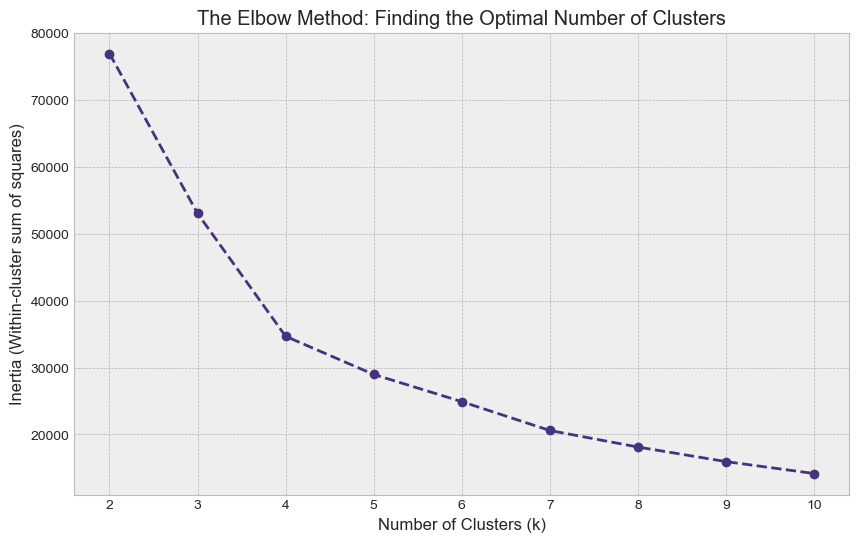

Clustering complete! 58980 users assigned to 4 clusters.


In [53]:
# A. Scale the Numbers (Age & Offspring)
# This ensures Age (18-60) doesn't overpower Offspring (0-3)
scaler = StandardScaler()
num_features = scaler.fit_transform(clean_df[['age', 'offspring_score']])

# B. Vectorize the Text
# TF-IDF gives more weight to unique words (like 'parent') and less to common ones ('life')
tfidf = TfidfVectorizer(stop_words='english', max_features=2000)
text_sparse = tfidf.fit_transform(clean_df['cleaned_essays'])

# C. Dimensionality Reduction (The "Topic" Maker)
# We compress 2000 word-dimensions into 20 "Topic" dimensions
svd = TruncatedSVD(n_components=20, random_state=42)
text_topics = svd.fit_transform(text_sparse)

# D. Combine into one Master Matrix
X = np.hstack((num_features, text_topics))

# --- 2. FIND THE OPTIMAL 'K' (THE ELBOW METHOD) ---

inertia = []
k_range = range(2, 11) # Checking for 2 to 10 clusters

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

# Plot the Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('The Elbow Method: Finding the Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True)
plt.show()

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clean_df['cluster'] = kmeans.fit_predict(X)

print(f"Clustering complete! {len(clean_df)} users assigned to {optimal_k} clusters.")